# Agrupamiento (Clustering)

**SI3015 - Fundamentos de Aprendizaje Automático**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN, KMeans
#from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, make_circles, make_moons

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    PolynomialFeatures,
    FunctionTransformer,
)

In [3]:
# Definamos el "random_state" para que los resultados sean reproducibles:
random_state=42

In [4]:
# Cambiemos la fuente de las gráficas de matplotlib:
plt.rc('font', family='serif', size=12)

## Ejemplo Práctico

Para los datasets planteados realice el siguiente proceso de clustering:

- Halle y grafique los clusters resultantes de aplicar K-medias con $K = 2$.
- Encuentre un buen valor de K mediante el método del codo y grafique los nuevos clusters.
- Halle la inercia en cada caso.


### Dataset 1

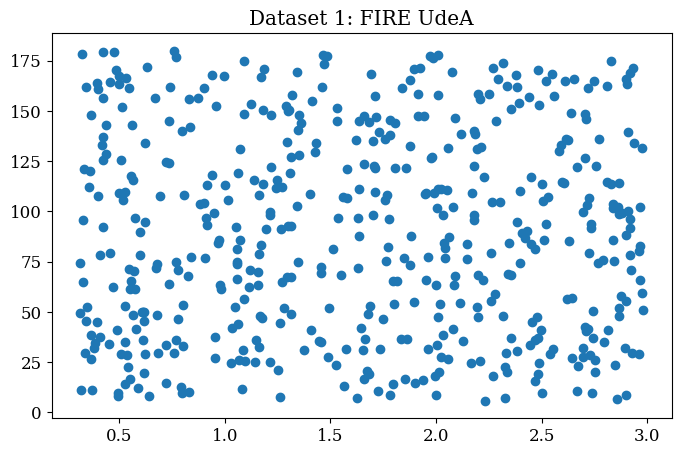

In [5]:
import pandas as pd
import numpy as np

# Cargar el dataset
df1 = pd.read_csv('data/dataset_sintetico_FIRE_UdeA.csv')

# Seleccionar solo las variables numéricas para el clustering
# Eliminamos 'label' ya que el agrupamiento es no supervisado
X1 = df1.drop(columns=['label'], errors='ignore')

# Convertir a array para que sea compatible con el resto del notebook
data = X1.values

# Visualización inicial (usando las dos primeras columnas como ejemplo)
fig, ax = plt.subplots()
ax.scatter(data[:,0], data[:,1])
ax.set_title("Dataset 1: FIRE UdeA")
fig.set_size_inches(8, 5)

In [6]:
#Definir el pipeline de pre-procesamiento
numeric_transformer = Pipeline(
    steps=[("scaler", StandardScaler())]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer,np.arange(data.shape[1])),
    ],
)

In [7]:
np.arange(data.shape[1])

array([0, 1, 2, 3, 4, 5, 6])

In [8]:
#Definimos el Pipeline de clustering con K = 2
clu_kmeans = Pipeline(steps=[("preprocessor", preprocessor), ("clustering",KMeans(n_clusters=2))])

In [9]:
#Entrenamos
clu_kmeans.fit(data)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('clustering', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

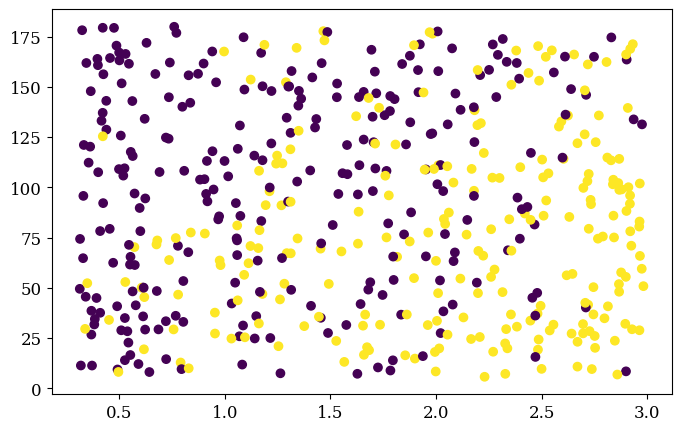

In [10]:
fig, ax = plt.subplots()
ax.scatter(data[:,0], data[:,1], c=clu_kmeans['clustering'].labels_)
fig.set_size_inches(5*1.6, 5)

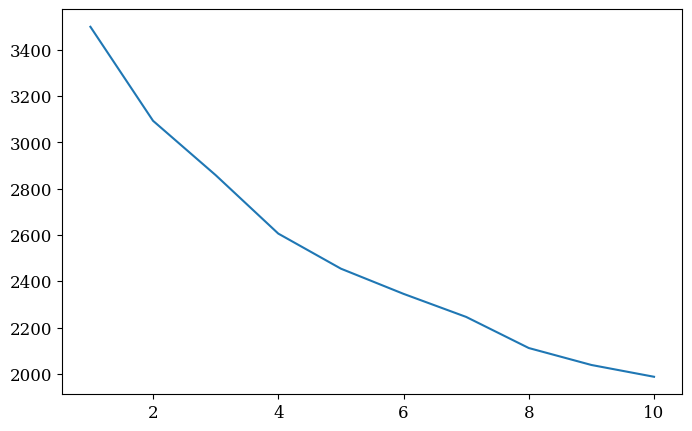

In [11]:
inert = []
k_range = list(range(1, 11))
for k in k_range:
    clu_kmeans = Pipeline(steps=[("preprocessor", preprocessor), ("clustering",KMeans(n_clusters=k))])
    clu_kmeans.fit(data)
    inert.append(clu_kmeans['clustering'].inertia_)

fig, ax = plt.subplots()
ax.plot(k_range, inert)
fig.set_size_inches(5*1.6, 5)

Daado que el "codo" está en $K = 2$, no aplicaremos K-medias de nuevo.

### Dataset 2

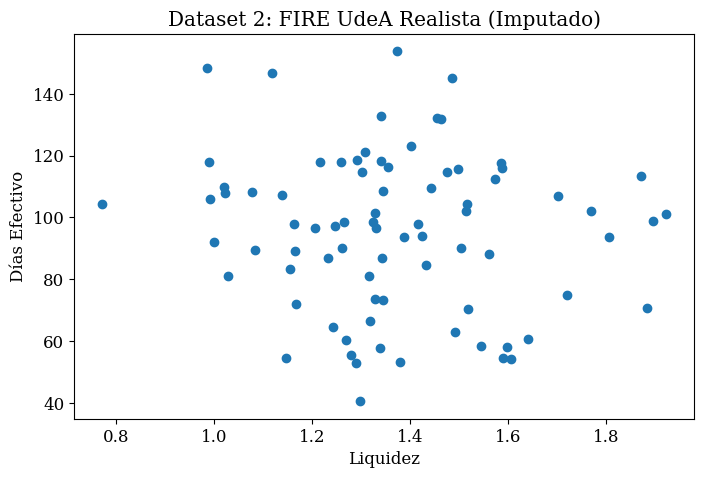

In [12]:
from sklearn.impute import SimpleImputer

# Cargar el dataset realista
df2 = pd.read_csv('data/dataset_sintetico_FIRE_UdeA_realista.csv')

# Seleccionar variables numéricas. 
# Excluimos 'anio' (temporal) y 'label' (objetivo) para el clustering.
# También excluimos 'unidad' por ser categórica/identificador.
cols_to_drop = ['label', 'anio', 'unidad']
X2 = df2.select_dtypes(include=[np.number]).drop(columns=cols_to_drop, errors='ignore')

# Manejo de valores nulos (Imputación por la mediana)
imputer = SimpleImputer(strategy='median')
data = imputer.fit_transform(X2)

# Visualización inicial (usando columnas como liquidez y dias_efectivo para el eje X/Y)
# Nota: liquidez es el índice 2 y dias_efectivo el 3 después de los drops previos
fig, ax = plt.subplots()
ax.scatter(data[:, 2], data[:, 3]) 
ax.set_title("Dataset 2: FIRE UdeA Realista (Imputado)")
ax.set_xlabel("Liquidez")
ax.set_ylabel("Días Efectivo")
fig.set_size_inches(8, 5)

In [13]:
#Definimos el Pipeline de clustering con K = 2
clu_kmeans = Pipeline(steps=[("preprocessor", preprocessor), ("clustering",KMeans(n_clusters=2))])
clu_kmeans.fit(data)
print(f'con K = 2: la inercia es {clu_kmeans["clustering"].inertia_}')

con K = 2: la inercia es 423.0450552156561


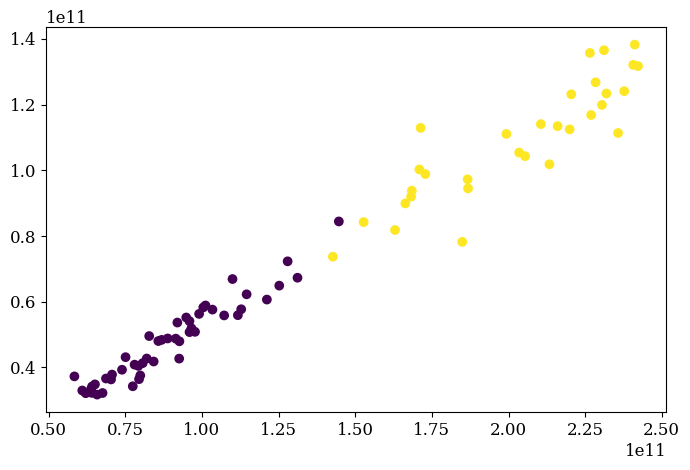

In [14]:
fig, ax = plt.subplots()
ax.scatter(data[:,0], data[:,1], c=clu_kmeans["clustering"].labels_)
fig.set_size_inches(5*1.6, 5)

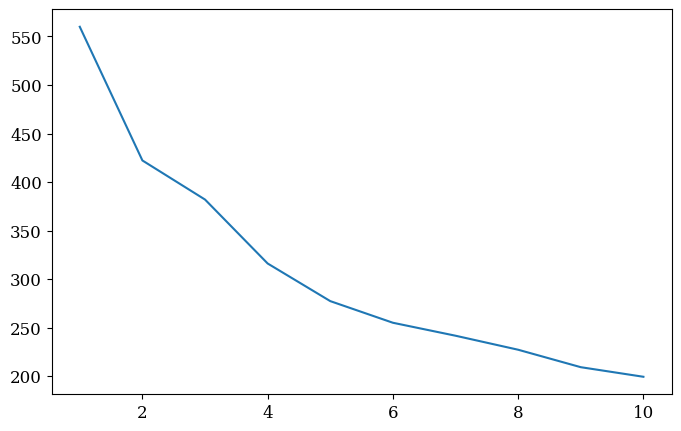

In [15]:
inert = []
k_range = list(range(1, 11))
for k in k_range:
    clu_kmeans = Pipeline(steps=[("preprocessor", preprocessor), ("clustering",KMeans(n_clusters=k))])
    clu_kmeans.fit(data)
    inert.append(clu_kmeans['clustering'].inertia_)

fig, ax = plt.subplots()
ax.plot(k_range, inert)
fig.set_size_inches(5*1.6, 5)

El "codo" está en $K = 4$.

In [16]:
#Definimos el Pipeline de clustering con K = 2
clu_kmeans = Pipeline(steps=[("preprocessor", preprocessor), ("clustering",KMeans(n_clusters=4))])
clu_kmeans.fit(data)
print(f'con K = 4: la inercia es {clu_kmeans["clustering"].inertia_}')

con K = 4: la inercia es 316.7059725596741


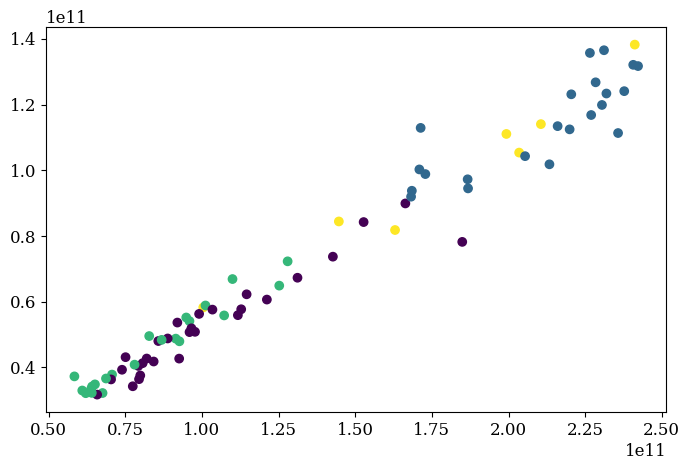

In [17]:
fig, ax = plt.subplots()
ax.scatter(data[:,0], data[:,1], c=clu_kmeans["clustering"].labels_)
fig.set_size_inches(5*1.6, 5)

In [18]:
#Definimos el Pipeline de clustering con K = 2
#clu_dbscan = Pipeline(steps=[("preprocessor", preprocessor), ("clustering",DBSCAN(eps=0.1, min_samples=10))])
clu_dbscan = Pipeline(steps=[("clustering",DBSCAN(eps=0.1, min_samples=10))])
clu_dbscan.fit(data)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('clustering', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.1
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",10
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance

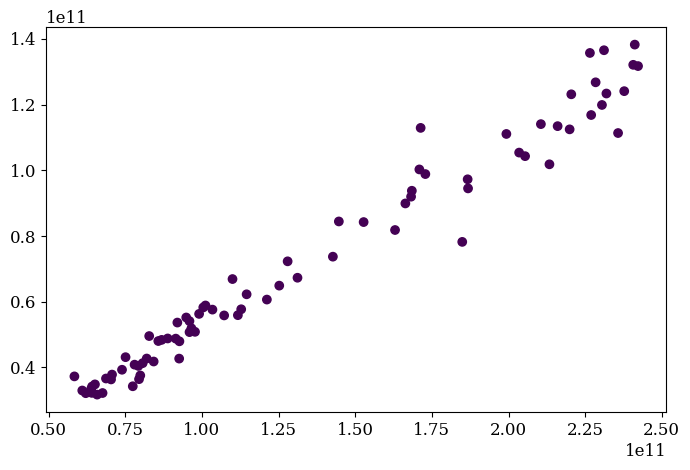

In [19]:
fig, ax = plt.subplots()
ax.scatter(data[:,0], data[:,1], c=clu_dbscan["clustering"].labels_)
fig.set_size_inches(5*1.6, 5)

In [20]:
np.unique(clu_dbscan["clustering"].labels_, return_counts=True)

(array([-1]), array([80]))